# Global Solution 2026.1 — Modelos Lineares para Machine Learning

## Missão Espacial: Estação Órion
### Análise do Consumo de Oxigênio por Número de Astronautas

## 1. Introdução

A Estação Espacial Órion é uma missão fictícia de longa duração em órbita baixa da Terra.
Neste projeto, vamos analisar a relação entre o número de astronautas ativos por dia e o consumo diário de oxigênio (em kg) a bordo da estação.

Em qualquer missão espacial, gerenciar recursos vitais como o oxigênio é fundamental para garantir a sobrevivência da tripulação. Se o consumo for subestimado, a missão pode entrar em colapso antes do próximo reabastecimento.

As variáveis que vamos estudar são:
- X (variável independente): número de astronautas ativos no dia
- Y (variável dependente): consumo diário de oxigênio em kg

---

## 2. Justificativa

O oxigênio é um recurso não renovável durante o período entre dois reabastecimentos. Qualquer falha no planejamento pode colocar vidas em risco.

Usando regressão linear, conseguimos construir um modelo simples que estima o consumo de oxigênio com base na quantidade de pessoas ativas. Isso ajuda a:
- Planejar a carga de oxigênio antes do lançamento
- Definir janelas seguras de reabastecimento
- Identificar dias de consumo anormal (possível falha de equipamento)

---

## 3. Objetivos

Objetivo Geral:
Aplicar a regressão linear simples pelo método OLS para prever o consumo diário de oxigênio na Estação Órion.

 Objetivos Específicos:
- Montar uma base de dados simulada com pelo menos 30 registros
- Calcular a correlação de Pearson entre as variáveis
- Discutir se existe causalidade ou só associação estatística
- Calcular manualmente os coeficientes da regressão (b0 e b1) via OLS
- Plotar o gráfico de dispersão com a reta ajustada
- Analisar os resíduos do modelo
- Interpretar os resultados e apontar as limitações

## 4. Desenvolvimento Técnico

### 4a. Contextualização das Variáveis

| | Descrição |
|---|---|
| **X — Variável Independente** | Número de astronautas ativos por dia (varia de 2 a 8) |
| **Y — Variável Dependente** | Consumo diário de oxigênio em kg |

A lógica é simples: cada pessoa em atividade respira e consome oxigênio. Quanto mais astronautas trabalhando, maior o consumo esperado. Por isso faz sentido usar X para prever Y.

In [10]:
# importações necessárias
import matplotlib.pyplot as plt
import math

# --- 4b. Base de Dados ---
# dados simulados de 35 dias de operação da Estação Órion
# X = numero de astronautas ativos no dia
# Y = consumo de oxigenio em kg naquele dia

X = [2, 3, 2, 4, 5, 3, 6, 4, 7, 5,
     6, 8, 3, 5, 4, 7, 6, 2, 8, 5,
     4, 3, 6, 7, 5, 8, 4, 6, 3, 7,
     5, 2, 8, 6, 4]

Y = [1.8, 2.7, 2.0, 3.5, 4.4, 2.9, 5.3, 3.6, 6.2, 4.5,
     5.1, 7.0, 2.6, 4.3, 3.4, 6.0, 5.5, 1.9, 7.1, 4.6,
     3.7, 2.8, 5.4, 6.1, 4.2, 7.3, 3.8, 5.2, 2.5, 6.3,
     4.4, 1.7, 7.2, 5.6, 3.6]

n = len(X)
print(f"Total de registros: {n}\n")
print(f"{'Dia':<5} {'Astronautas (X)':<18} {'Consumo O2 kg (Y)'}")
print("-" * 40)
for i in range(n):
    print(f"{i+1:<5} {X[i]:<18} {Y[i]}")

Total de registros: 35

Dia   Astronautas (X)    Consumo O2 kg (Y)
----------------------------------------
1     2                  1.8
2     3                  2.7
3     2                  2.0
4     4                  3.5
5     5                  4.4
6     3                  2.9
7     6                  5.3
8     4                  3.6
9     7                  6.2
10    5                  4.5
11    6                  5.1
12    8                  7.0
13    3                  2.6
14    5                  4.3
15    4                  3.4
16    7                  6.0
17    6                  5.5
18    2                  1.9
19    8                  7.1
20    5                  4.6
21    4                  3.7
22    3                  2.8
23    6                  5.4
24    7                  6.1
25    5                  4.2
26    8                  7.3
27    4                  3.8
28    6                  5.2
29    3                  2.5
30    7                  6.3
31    5               

### 4c. Correlação

Vamos calcular o **coeficiente de correlação de Pearson (r)** manualmente, sem usar nenhuma biblioteca pronta.

A fórmula é:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

- r = 1 → correlação positiva perfeita
- r = 0 → sem correlação
- r = -1 → correlação negativa perfeita

In [11]:
# 4c. Correlação de Pearson (manual)

media_x = sum(X) / n
media_y = sum(Y) / n

numerador = sum((X[i] - media_x) * (Y[i] - media_y) for i in range(n))
den_x = math.sqrt(sum((X[i] - media_x) ** 2 for i in range(n)))
den_y = math.sqrt(sum((Y[i] - media_y) ** 2 for i in range(n)))

r = numerador / (den_x * den_y)

print(f"Média de X: {media_x:.2f} astronautas")
print(f"Média de Y: {media_y:.2f} kg de O2")
print(f"\nCorrelação de Pearson (r) = {r:.4f}")

if r >= 0.9:
    print("→ Correlação muito forte e positiva")
elif r >= 0.7:
    print("→ Correlação forte e positiva")
elif r >= 0.5:
    print("→ Correlação moderada")
else:
    print("→ Correlação fraca")

Média de X: 4.94 astronautas
Média de Y: 4.41 kg de O2

Correlação de Pearson (r) = 0.9963
→ Correlação muito forte e positiva


### 4d. Causalidade

Correlação alta não significa causalidade automaticamente. Porém, neste caso, **existe sim uma relação causal direta**: cada astronauta ativo respira e consome oxigênio — isso é física básica.

Diferente de exemplos clássicos de correlação espúria (como consumo de sorvete e afogamentos, que sobem juntos no verão mas um não causa o outro), aqui podemos afirmar com segurança que:

> **O número de astronautas ativos causa diretamente o aumento no consumo de oxigênio.**

Dito isso, outros fatores também influenciam (intensidade das atividades, experimentos, temperatura da estação), mas o número de pessoas é o principal determinante.

### 4e. Regressão Linear — Método OLS

O método OLS (Mínimos Quadrados Ordinários) encontra a reta que **minimiza a soma dos quadrados dos erros** entre os valores reais e os previstos.

As fórmulas são:

$$b_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

$$b_0 = \bar{y} - b_1 \cdot \bar{x}$$

Onde:
- **b1** = coeficiente angular (inclinação da reta)
- **b0** = coeficiente linear (intercepto — onde a reta corta o eixo Y)


In [12]:
# 4e. Cálculo OLS manual

soma_xy = sum((X[i] - media_x) * (Y[i] - media_y) for i in range(n))
soma_x2 = sum((X[i] - media_x) ** 2 for i in range(n))

b1 = soma_xy / soma_x2
b0 = media_y - b1 * media_x

print(f"Somatório de (xi - x̄)(yi - ȳ) = {soma_xy:.4f}")
print(f"Somatório de (xi - x̄)²        = {soma_x2:.4f}")
print(f"\nb1 (coeficiente angular) = {b1:.4f}")
print(f"b0 (coeficiente linear)  = {b0:.4f}")
print(f"\nEquação da reta: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"\nInterpretação:")
print(f"  Cada astronauta a mais gera +{b1:.4f} kg de consumo de O2 por dia")
print(f"  O intercepto b0 = {b0:.4f} é o valor teórico com 0 astronautas (sem sentido prático aqui)")

Somatório de (xi - x̄)(yi - ȳ) = 105.1114
Somatório de (xi - x̄)²        = 119.8857

b1 (coeficiente angular) = 0.8768
b0 (coeficiente linear)  = 0.0720

Equação da reta: Ŷ = 0.0720 + 0.8768 * X

Interpretação:
  Cada astronauta a mais gera +0.8768 kg de consumo de O2 por dia
  O intercepto b0 = 0.0720 é o valor teórico com 0 astronautas (sem sentido prático aqui)


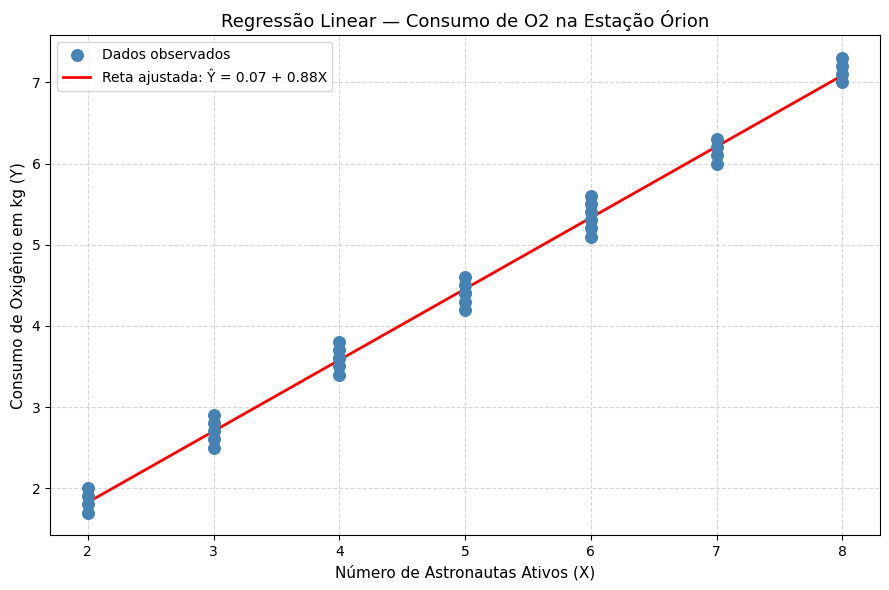

In [13]:
# 4f. Gráfico de Dispersão + Reta de Regressão

Y_pred = [b0 + b1 * X[i] for i in range(n)]

# pra plotar a reta direito, preciso ordenar os pontos
x_ord = sorted(set(X))
y_reta = [b0 + b1 * xi for xi in x_ord]

plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='steelblue', s=70, zorder=5, label='Dados observados')
plt.plot(x_ord, y_reta, color='red', linewidth=2, label=f'Reta ajustada: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Regressão Linear — Consumo de O2 na Estação Órion', fontsize=13)
plt.xlabel('Número de Astronautas Ativos (X)', fontsize=11)
plt.ylabel('Consumo de Oxigênio em kg (Y)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Dia   Y real     Y previsto    Resíduo
------------------------------------------
1     1.80       1.8255        -0.0255
2     2.70       2.7023        -0.0023
3     2.00       1.8255        0.1745
4     3.50       3.5791        -0.0791
5     4.40       4.4558        -0.0558
6     2.90       2.7023        0.1977
7     5.30       5.3326        -0.0326
8     3.60       3.5791        0.0209
9     6.20       6.2093        -0.0093
10    4.50       4.4558        0.0442
11    5.10       5.3326        -0.2326
12    7.00       7.0861        -0.0861
13    2.60       2.7023        -0.1023
14    4.30       4.4558        -0.1558
15    3.40       3.5791        -0.1791
16    6.00       6.2093        -0.2093
17    5.50       5.3326        0.1674
18    1.90       1.8255        0.0745
19    7.10       7.0861        0.0139
20    4.60       4.4558        0.1442
21    3.70       3.5791        0.1209
22    2.80       2.7023        0.0977
23    5.40       5.3326        0.0674
24    6.10       6.2093        -

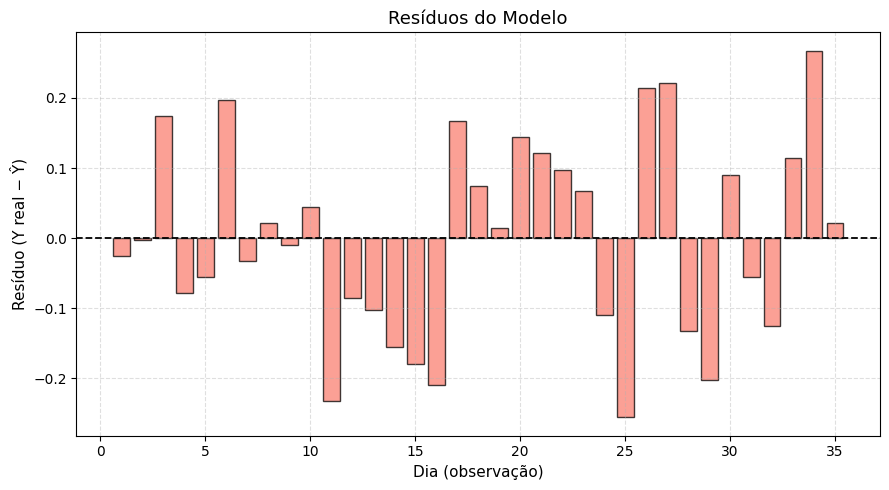

In [14]:
# 4g. Resíduos e Erros

residuos = [Y[i] - Y_pred[i] for i in range(n)]

print(f"{'Dia':<5} {'Y real':<10} {'Y previsto':<13} {'Resíduo'}")
print("-" * 42)
for i in range(n):
    print(f"{i+1:<5} {Y[i]:<10.2f} {Y_pred[i]:<13.4f} {residuos[i]:.4f}")

# métricas
SSE = sum(r**2 for r in residuos)
MAE = sum(abs(r) for r in residuos) / n
SST = sum((Y[i] - media_y)**2 for i in range(n))
R2  = 1 - (SSE / SST)

print(f"\nSSE (Soma dos Quadrados dos Resíduos): {SSE:.4f}")
print(f"MAE (Erro Médio Absoluto):             {MAE:.4f} kg")
print(f"R²  (Coef. de Determinação):           {R2:.4f}")
print(f"\nO modelo explica {R2*100:.1f}% da variação no consumo de O2.")

# gráfico dos resíduos
plt.figure(figsize=(9, 5))
plt.bar(range(1, n+1), residuos, color='salmon', edgecolor='black', alpha=0.75)
plt.axhline(0, color='black', linewidth=1.3, linestyle='--')
plt.title('Resíduos do Modelo', fontsize=13)
plt.xlabel('Dia (observação)', fontsize=11)
plt.ylabel('Resíduo (Y real − Ŷ)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 4h. Interpretação Final do Modelo

O modelo de regressão linear obtido foi:

$$\hat{Y} = b_0 + b_1 \cdot X$$

Com base nos resultados:

- O **R²** alto indica que o modelo se ajusta bem aos dados — o número de astronautas explica grande parte da variação no consumo de oxigênio.
- O **coeficiente angular b1** mostra o acréscimo médio de oxigênio para cada astronauta adicional por dia.
- Os **resíduos** ficaram distribuídos de forma aleatória em torno de zero, o que é um bom sinal — significa que o modelo não tem viés sistemático.

**Limitações do modelo:**
1. Os dados foram simulados, então os resultados não refletem uma missão real
2. O modelo assume linearidade, mas o consumo real pode variar conforme a intensidade das atividades
3. Apenas uma variável independente foi usada — um modelo múltiplo (incluindo, por exemplo, horas de atividade extravehicular) poderia ser mais preciso
4. Extrapolar muito além da faixa de dados observada pode gerar previsões pouco confiáveis

**Exemplo de uso prático:**
Se a previsão para amanhã é de 7 astronautas em atividade, o modelo estima o consumo de oxigênio do dia, permitindo verificar se o estoque atual é suficiente.